# Notebook \#3: Modelling

# Eviny Charging Curve Classification LSTM 
#### by Sebastian Einar Salas Røkholt
----

### Index
**1. Setup** </br>
**2. Data Exploration, Wrangling and Preprocessing**</br>
**3. Modelling**</br>
**4. Model Evaluation and Selection**</br>
**+++**</br>


### Introduction
The aim of this notebook is ...

### 1. Setup

In [1]:
import os
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Sampler
import torch.nn.utils.rnn as rnn_utils
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from typing import Tuple, Union, List

RANDOM_SEED = 42
TRAIN_MODEL = False
MODEL_PATH = '../Models/LSTM_varseq_model_2.pth'

# Notebook settings
%matplotlib inline
pd.options.mode.copy_on_write = True
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:.2f}'.format  # By default, display all floats with two decimals

#### 1.1 Feature selection 
In order to predict `soc` and `power` output at the next timestep/minute, the model will use the `soc` and `power` values from the `sequence_length` (e.g. 15) previous timesteps/minutes. In addition, there are two static (non time-dependent, per-session) features that we believe the model will use to enhance its predictive abilities. The first static feature is `temp`, the approximate ambient temperature (rounded to the nearest integer) at the start of the charging session. Charging speed is directly influenced by the vehicle's battery temperature, because at lower temperatures, the chemical processes in the battery slow down. Lithium-ion batteries may also experience lithium plating if charged to quickly at low temperatures, so both vehicle and charging station manufacturers place automatic restrictions that limit the energy transfer. As we do not have access to battery temperature data from each vehciel, we have collected ambient air temperature  data instead, which we believe might be a good explanatory environmental variable as the ambient temperature is one of several causal factors that influence the battery temperature. Other factors are vehicle usage, charging duration, and the vehicle's thermal management system.
The second static feature we will be using is `nominal_power`, which is the charging station's maximum power output as stated by the manufacturer. As different types of charging stations are likely to have significantly different power output distributions, we believe that this static feature will help the model determine what the likely value range will be, especially at the start of the charging session. 

The dataset contains a few other features, but these will not be used for modelling. This is mainly, because these features are either derived from other features or were used in the feature engineering step to calculate other derived features. For example, `energy` (in kWh) is simply the `power` (in kW) aggregated to the hour, while `lat` (latitude) and `lon` (longitude) were used to retrieve temperature data. The geographical position of the charging station is unlikely to be a useful predictor for our target variables. 

In [2]:
# Load the cleaned dataset
df = pd.read_parquet("../Data/etron55-charging-sessions.parquet")
print(f"Features: {df.columns}")

all_features = ["charging_id", "minutes_elapsed", "power", "soc", "temp", "nominal_power"]
fixed_features = ["temp", "nominal_power"]
target_features = ["power", "soc"]
input_features = fixed_features + target_features

df = df[all_features]
df.head(10)

Features: Index(['charging_id', 'timestamp', 'minutes_elapsed', 'soc', 'power', 'energy',
       'charger_category', 'nominal_power', 'temp', 'lat', 'lon'],
      dtype='object')


,charging_id,minutes_elapsed,power,soc,temp,nominal_power
0,0,0,89.44,40.00,4,150.00
1,0,1,92.75,41.00,4,150.00
2,0,2,94.81,43.00,4,150.00
3,0,3,95.68,45.00,4,150.00
4,0,4,96.88,47.00,4,150.00
5,0,5,97.62,48.00,4,150.00
6,0,6,98.87,50.00,4,150.00
7,0,7,99.58,52.00,4,150.00
8,0,8,99.72,54.00,4,150.00
9,0,9,99.69,55.00,4,150.00


In [3]:
df.tail()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power
1590118,12657311,11,126.05,57.00,7,360.00
1590119,12657311,12,126.95,60.00,7,360.00
1590120,12657311,13,127.97,62.00,7,360.00
1590121,12657311,14,128.01,65.00,7,360.00
1590122,12657311,15,129.47,67.00,7,360.00


## 2 - Data preparation

#### 2.1 - Splitting the data 
The code below splits the dataset into training, validation and test sets. </br>
`GroupShuffleSplit` ensures that a charging session isn't split across multiple sets.

In [10]:
def split_data(df: pd.DataFrame, test_size: float=0.2, validation_size: float=0.1) \
    -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split the dataset into train, validation, and test sets by charging_id grouping.
    
    :param df: Original dataframe containing all charging sessions
    :param test_size: Proportion of data to use for testing
    :param validation_size: Proportion of the remaining data (after test split) to use for validation
    :return: train_df, val_df, test_df DataFrames
    """
    #Test split
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_SEED)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df['charging_id']))
    train_val_df = df.iloc[train_val_idx]

    #Validation split
    adj_val_size = validation_size / (1 - test_size)  # Adjust validation size based on the remaining dataset after test split
    gss_val = GroupShuffleSplit(n_splits=1, test_size=adj_val_size, random_state=RANDOM_SEED)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['charging_id']))

    # Performs the splits on the original dataset
    train_df = train_val_df.iloc[train_idx]
    val_df = train_val_df.iloc[val_idx]
    test_df = df.iloc[test_idx]
    return train_df, val_df, test_df


train_df, val_df, test_df = split_data(df)
print(f"Training set size: {len(train_df)} ({round(100*(len(train_df)/len(df)), 1)}%)\n"
      f"Validation set size: {len(val_df)} ({round(100*(len(val_df)/len(df)), 1)}%)\n"
      f"Test set size: {len(test_df)} ({round(100*(len(test_df)/len(df)), 1)}%)\n"
      f"Total size: {len(df)}")

Training set size: 1113061 (70.0%)
Validation set size: 159426 (10.0%)
Test set size: 317636 (20.0%)
Total size: 1590123


In [11]:
train_df.head()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power
0,0,0,89.44,40.00,4,150.00
1,0,1,92.75,41.00,4,150.00
2,0,2,94.81,43.00,4,150.00
3,0,3,95.68,45.00,4,150.00
4,0,4,96.88,47.00,4,150.00


#### 2.2 - Data normalisation


In [13]:
# Creates scalers
fixed_features_scaler = MinMaxScaler(feature_range=(0, 1))
power_scaler = MinMaxScaler(feature_range=(0, 1))
soc_scaler = MinMaxScaler(feature_range=(0, 1))

# Fits scalers on training data only
fixed_features_scaler.fit(train_df[fixed_features])
power_scaler.fit(train_df[["power"]])
soc_scaler.fit(train_df[["soc"]])

# Transform train, val, test sets
train_df[fixed_features] = fixed_features_scaler.transform(train_df[fixed_features])
val_df[fixed_features] = fixed_features_scaler.transform(val_df[fixed_features])
test_df[fixed_features] = fixed_features_scaler.transform(test_df[fixed_features])
train_df["power"] = power_scaler.transform(train_df[["power"]])
val_df["power"] = power_scaler.transform(val_df[["power"]])
test_df["power"] = power_scaler.transform(test_df[["power"]])
train_df["soc"] = soc_scaler.transform(train_df[["soc"]])
val_df["soc"] = soc_scaler.transform(val_df[["soc"]])
test_df["soc"] = soc_scaler.transform(test_df[["soc"]])

train_df.head()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power
0,0,0,0.33,0.39,0.56,0.22
1,0,1,0.35,0.40,0.56,0.22
2,0,2,0.35,0.42,0.56,0.22
3,0,3,0.36,0.44,0.56,0.22
4,0,4,0.36,0.46,0.56,0.22


 ### 2.3 - Building the datasets

In [7]:
class ChargingSessionDataset(Dataset):

    """
    A custom PyTorch Dataset class to represent a dataset of charging sessions (sequences), 
    where each session is returned as (X, y, length). 
    The sessions attribute contains all charging sessions in the dataset as (X, y, length), where: 
        X shape: (session length, input size)
        y shape: (session length, output size)
        length:  scalar int. The length of the sequence / duration of the charging session in minutes
    """
    def __init__(self, df: pd.DataFrame, input_features: List[str], target_features: List[str], shift_next_step: bool=True):
        """
        Args:
            df (pd.DataFrame): DataFrame containing charging session data.
            input_features (list): List of column names for input features.
            target_features (list): List of column names for target features.
            shift_next_step (bool): If True, shifts target labels for next-step prediction (X[t] -> y[t+1]).
        """
        super().__init__()
        self.input_features = input_features
        self.target_features = target_features
        self.sessions = []

        # Groups by charging session
        for session_id, session_df in df.groupby('charging_id', observed=False):
            session_df = session_df.sort_values('minutes_elapsed')
            session_x = session_df[self.input_features].values
            session_y = session_df[self.target_features].values

            if shift_next_step and len(session_x) > 1:
                session_x = session_x[:-1]
                session_y = session_y[1:]

            if len(session_x) > 0:
                self.sessions.append((session_x, session_y))

    def __len__(self):
        return len(self.sessions)

    def __getitem__(self, idx):
        x, y = self.sessions[idx]
        length = x.shape[0]
        return x, y, length


class BucketBatchSampler(Sampler):
    """
    Groups charging sessions of similar length into batches to reduce padding.
    """
    def __init__(self, dataset: ChargingSessionDataset, batch_size: int, shuffle: bool=True):
        """
        Args:
            dataset (ChargingSessionDataset): Dataset to sample from.
            batch_size (int): Number of sessions per batch.
            shuffle (bool): If True, shuffles batches at initialization and every epoch.
        """
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        
        # Sorts the dataset indices by session length (asc)
        lengths = []
        for (i, (x, y)) in enumerate(dataset.sessions):
            lengths.append((i, x.shape[0]))
        self.sorted_indices = sorted(lengths, key=lambda tup: tup[1])
        self.sorted_indices = [tup[0] for tup in self.sorted_indices]

        # Chunks the sequences into batches
        self.batches = []
        for i in range(0, len(self.sorted_indices), self.batch_size):
            self.batches.append(self.sorted_indices[i : i + self.batch_size])
        
        if self.shuffle:
            # at instanciation, we shuffle the batches
            random.shuffle(self.batches)

    def __iter__(self):
        """Yields batches of indices, optionally shuffled per epoch."""
        if self.shuffle:
            # re-shuffles the batch order every epoch
            random.shuffle(self.batches)
        for batch_inds in self.batches:
            yield batch_inds

    def __len__(self):
        return math.ceil(len(self.sorted_indices) / self.batch_size)


def session_collate_fn(batch: List[Tuple[np.ndarray, np.ndarray, int]]):
    """
    Pads sequences to the same length and converts them into tensors for batch processing.

    Args:
        batch: List of tuples containing (X, y, session length) for each session.

    Returns: Tuple of three tensors:
            - padded_x: Padded input features with shape (batch_size, max_length, input_size).
            - padded_y: Padded target features with shape (batch_size, max_length, output_size).
            - lengths: Tensor of session lengths with shape (batch_size,).
    """
    all_x, all_y, lengths = zip(*batch)
    max_len = max(lengths)
    padded_x = []
    padded_y = []

    for x, y in zip(all_x, all_y):
        seq_len = x.shape[0]
        x_padded = np.zeros((max_len, x.shape[1]), dtype=np.float32)
        x_padded[:seq_len, :] = x
        y_padded = np.zeros((max_len, y.shape[1]), dtype=np.float32)
        y_padded[:seq_len, :] = y
        padded_x.append(x_padded)
        padded_y.append(y_padded)

    # converts list of ndarrays -> single ndarray -> tensor
    padded_x = torch.from_numpy(np.stack(padded_x, axis=0)).float()
    padded_y = torch.from_numpy(np.stack(padded_y, axis=0)).float()
    lengths  = torch.tensor(lengths, dtype=torch.long)

    return padded_x, padded_y, lengths


In [8]:
BATCH_SIZE = 128
NUM_WORKERS = 24

# Builds a PyTorch Dataset where each instance is a charging session / sequence (i.e. groups readings to charging_id)
train_dataset = ChargingSessionDataset(train_df, input_features, target_features, shift_next_step=True)
val_dataset   = ChargingSessionDataset(val_df,   input_features, target_features, shift_next_step=True)
test_dataset  = ChargingSessionDataset(test_df,  input_features, target_features, shift_next_step=True)

# Sequence length-based sampling for each batch
train_sampler = BucketBatchSampler(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_sampler   = BucketBatchSampler(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_sampler = BucketBatchSampler(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Instanciates the DataLoaders for each dataset, padding each sequence in the batch to the same length
train_loader = DataLoader(dataset=train_dataset, batch_sampler=train_sampler, 
                          collate_fn=session_collate_fn, num_workers=NUM_WORKERS)
val_loader = DataLoader(dataset=val_dataset, batch_sampler=val_sampler, 
                        collate_fn=session_collate_fn, num_workers=NUM_WORKERS)
test_loader  = DataLoader(dataset=test_dataset, batch_sampler=test_sampler, 
                          collate_fn=session_collate_fn, num_workers=NUM_WORKERS)

## Modelling

In [9]:
class MultivariateLSTM(nn.Module):
    """
    LSTM that predicts multiple outputs for each valid time step.
    """
    def __init__(self, input_size, hidden_layer_size, output_size, num_layers):
        super(MultivariateLSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_layer_size, 
            num_layers=num_layers, 
            batch_first=True
        )
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, x, seq_lengths):
        """
        :param x: Padded input tensor of shape (batch_size, max_seq_len, input_size)
        :param seq_lengths: 1D tensor with actual lengths (batch_size,)
        :return:
          out: Padded output of shape (batch_size, max_seq_len, output_size)
          out_lengths: same as seq_lengths (for completeness)
        """
        # Pack the padded sequence so LSTM ignores the padded steps
        packed_x = rnn_utils.pack_padded_sequence(
            x, 
            seq_lengths.cpu(),  # lengths must be on CPU for pack_padded_sequence
            batch_first=True, 
            enforce_sorted=False
        )
        
        # Forward pass and unpack so we get a padded output of shape (B, T_max, hidden_layer_size)
        packed_out, (h, c) = self.lstm(packed_x)
        out, out_lengths = rnn_utils.pad_packed_sequence(packed_out, batch_first=True)
        
        # Apply the final linear layer
        out = self.linear(out)  # (batch_size, T_max, output_size)
        
        return out, out_lengths

In [10]:
def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, 
                num_epochs: int = 10, initial_lr: float = 0.001, plot_loss: bool = True
                ) -> None:
    """
    Trains an LSTM-based PyTorch model on variable-length sequential data.

    Args:
        model (nn.Module): The model to train, which must support variable-length sequences.
        train_loader (DataLoader): DataLoader for training data, yielding batches of 
                                   (inputs, targets, lengths).
        val_loader (DataLoader): DataLoader for validation data, with the same format as train_loader.
        num_epochs (int, optional): Number of training epochs. Default is 10.
        initial_lr (float, optional): Initial learning rate for the Adam optimizer. Default is 0.001.
        plot_loss (bool, optional): Whether to plot training and validation loss after training. Default is True.

    Training Details:
        - The model processes padded sequences of shape (batch_size, max_seq_len, input_size), where 
          max_seq_len varies per batch depending on the longest sequence.
        - Uses masking to exclude padded timesteps from the loss calculation, ensuring that only valid
          timesteps contribute to the loss.
        - Computes Mean Squared Error (MSE) loss for each valid timestep:
            - The loss for each timestep is calculated independently, summed across all timesteps, 
              and then divided by the total number of valid (non-padded) timesteps in the batch.
        - Optimizes the model parameters using the Adam optimizer with a learning rate scheduler 
          that reduces the learning rate when the validation loss plateaus.

    Returns:
        None. Trains the model in-place and optionally plots the training and validation loss trends.
    """
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()

    # Uses MSELoss without reduction in order to mask out padded steps later
    criterion = nn.MSELoss(reduction='none')
    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
    if plot_loss:
        train_losses, val_losses = [], []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        total_train_valid_steps = 0  # number of "valid", i.e. non-padded, timesteps
        for X_batch, Y_batch, lengths in train_loader:
            X_batch, Y_batch, lengths = X_batch.to(device), Y_batch.to(device), lengths.to(device)
            optimizer.zero_grad()

            # Forward pass
            # pred_padded: is of shape (B, T_max, 2), where T_max is the max seq len
            pred_padded, out_lengths = model(X_batch, lengths) 
            # Applies a mask to the padded timesteps so they are ignored
            B, T_max, _ = pred_padded.shape
            mask = torch.zeros(B, T_max, dtype=torch.bool, device=device)
            for i in range(B):
                mask[i, :lengths[i]] = True

            # Calculates the loss (mean MSE) from valid timesteps
            loss_per_timestep = criterion(pred_padded, Y_batch)  # [B, T_max, output_size]
            loss_per_timestep = loss_per_timestep.sum(dim=-1)
            valid_loss = loss_per_timestep[mask].sum()
            valid_steps = mask.sum().item()  # total non-padded steps
            loss = valid_loss / valid_steps
            
            # Performs backpropagation, updates model weights
            loss.backward()
            optimizer.step()

            # Tracks the training loss
            epoch_train_loss += valid_loss.item()
            total_train_valid_steps += valid_steps
        avg_epoch_train_loss = epoch_train_loss / total_train_valid_steps

        # Calculates and tracks the validation loss
        model.eval()
        epoch_val_loss = 0.0
        total_val_valid_steps = 0
        with torch.no_grad():
            for X_batch, Y_batch, lengths in val_loader:
                X_batch, Y_batch, lengths = X_batch.to(device), Y_batch.to(device), lengths.to(device)
                pred_padded, out_lengths = model(X_batch, lengths)
                B, T_max, _ = pred_padded.shape
                mask = torch.zeros(B, T_max, dtype=torch.bool, device=device)
                for i in range(B):
                    mask[i, :lengths[i]] = True
                loss_per_timestep = criterion(pred_padded, Y_batch)
                loss_per_timestep = loss_per_timestep.sum(dim=-1)
                valid_loss = loss_per_timestep[mask].sum()
                valid_steps = mask.sum().item()
                epoch_val_loss += valid_loss.item()
                total_val_valid_steps += valid_steps
        avg_epoch_val_loss = epoch_val_loss / total_val_valid_steps

        # Steps the learning rate scheduler
        scheduler.step(avg_epoch_val_loss)

        if (epoch + 1) % 5 == 0 and epoch > 5:
            print(f"Epoch {epoch+1}/{num_epochs}, LR={scheduler.get_last_lr()[0]:.3e}, "
                  f"TrainLoss={avg_epoch_train_loss:.6f}, ValLoss={avg_epoch_val_loss:.6f}")
            
        if plot_loss:
            train_losses.append(avg_epoch_train_loss)
            val_losses.append(avg_epoch_val_loss)

    print('Training complete.')

    if plot_loss:
        # Plot training vs validation loss
        plt.figure(figsize=(8,5))
        plt.plot(range(1, len(train_losses)+1), train_losses, label='Train')
        plt.plot(range(1, len(val_losses)+1), val_losses, label='Val')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Training & Validation MSE (per valid timestep)')
        plt.show()


In [11]:
# Setting the model hyperparameters
input_size = len(input_features)  # power, soc, minutes_elapsed, temp and nominal_power
output_size = len(target_features)  # Predicting power and soc for the next time step
HIDDEN_LAYER_SIZE = 60
NUM_HIDDEN_LAYERS = 4
N_TRAINING_EPOCHS = 50

# Defining the network architecture and hyperparameters
model = MultivariateLSTM(input_size, HIDDEN_LAYER_SIZE, output_size, NUM_HIDDEN_LAYERS)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

MultivariateLSTM(
  (lstm): LSTM(4, 60, num_layers=4, batch_first=True)
  (linear): Linear(in_features=60, out_features=2, bias=True)
)

In [12]:
# Running the training loop
if TRAIN_MODEL:
    print(f"Training on device {device}...")
    train_model(model, train_loader, val_loader, num_epochs=N_TRAINING_EPOCHS, plot_loss=True)
    torch.save(model.state_dict(), MODEL_PATH)
elif not TRAIN_MODEL and os.path.exists(MODEL_PATH): 
    # Load the model
    model.load_state_dict(torch.load(MODEL_PATH))
    model.eval()
else:
    print(f"TRAIN_MODEL is set to False, but there is no pre-trained model saved at path {MODEL_PATH}")
    print(f"Training a new model on device {device}...")
    train_model(model, train_loader, val_loader, num_epochs=10, plot_loss=True)
    torch.save(model.state_dict(), MODEL_PATH)

/tmp/ipykernel_1486/623458699.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH))


## Prediction

In [13]:
# Select a batch from the test dataset
batch_index = 0  # The index of the batch we want
test_loader_iter = iter(test_loader)
for i in range(batch_index):
    next(test_loader_iter)
X_test_batch, Y_test_batch, lengths_test = next(test_loader_iter)
print("Batch lengths:", lengths_test)
assert len(lengths_test) == BATCH_SIZE  # will likely fail on last batch in the dataset

X_test_batch = X_test_batch.to(device)
Y_test_batch = Y_test_batch.to(device)
lengths_test = lengths_test.to(device)

# Run predictions on all charging sessions in the batch
model.eval()
with torch.no_grad():
    y_pred_padded, out_lengths = model(X_test_batch, lengths_test)
    # y_pred_padded: shape [B, T_max, output_size]
    # print(y_pred_padded)

Batch lengths: tensor([1, 4, 4, 5, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
        8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9])


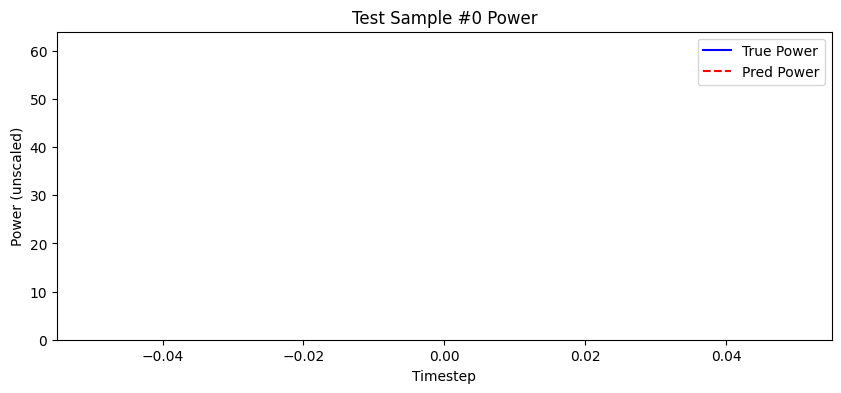

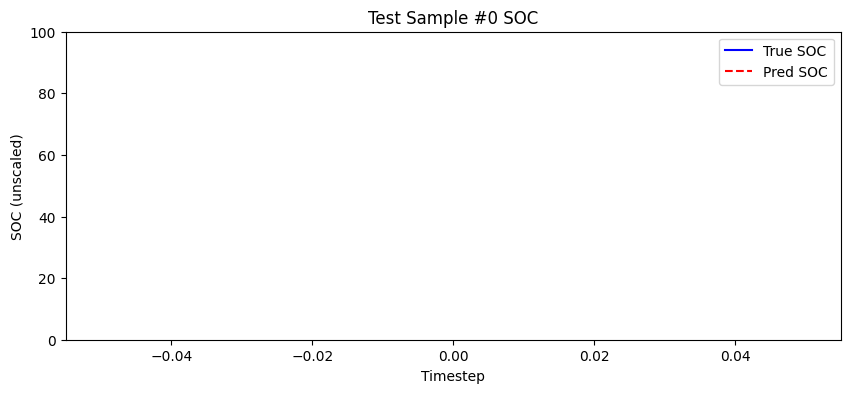

In [14]:
# Selects the predictions and true values for a single session in the test batch
i_sample = 0
sample_len = lengths_test[i_sample].item()
pred_np = y_pred_padded[i_sample, :sample_len].cpu().numpy()
true_np = Y_test_batch[i_sample, :sample_len].cpu().numpy()
# print(i_sample, "\n")
# print(pred_np, "\n____________\n")
# print(true_np)

# Inverse transforms to original scale
pred_power = power_scaler.inverse_transform(pred_np[:, [0]]).ravel()
pred_soc   = soc_scaler.inverse_transform(pred_np[:, [1]]).ravel()
true_power = power_scaler.inverse_transform(true_np[:, [0]]).ravel()
true_soc   = soc_scaler.inverse_transform(true_np[:, [1]]).ravel()

# Plots the result
time_axis = np.arange(sample_len)  # or your original minutes_elapsed if you stored them
plt.figure(figsize=(10,4))
plt.plot(time_axis, true_power, label='True Power', color='b')
plt.plot(time_axis, pred_power, label='Pred Power', color='r', linestyle='--')
plt.xlabel('Timestep')
plt.ylabel('Power (unscaled)')
plt.ylim(bottom=0)
plt.title('Test Sample #0 Power')
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(time_axis, true_soc, label='True SOC', color='b')
plt.plot(time_axis, pred_soc, label='Pred SOC', color='r', linestyle='--')
plt.xlabel('Timestep')
plt.ylabel('SOC (unscaled)')
plt.ylim(0, 100)
plt.title('Test Sample #0 SOC')
plt.legend()
plt.show()

In [15]:
# for idx in range(len(test_dataset)):
#     X_arr, Y_arr, length_ = test_dataset[idx]
#     print(f"test_dataset[{idx}]: length={length_}, X.shape={X_arr.shape}, Y.shape={Y_arr.shape}")


In [16]:
def predict_session_of_length(
        model: nn.Module, dataset: ChargingSessionDataset, bucket_sampler: BucketBatchSampler, 
        target_length: int, session_index_of_that_length: int, device: torch.device, 
        power_scaler: MinMaxScaler, soc_scaler: MinMaxScaler, skip_pred_first_n: int = 1, 
        skip_true_first_n: int = 0, num_workers: int = 0
    ):
    """
    Searches through the bucket sampler for a batch containing at least 
    `session_index_of_that_length + 1` sessions of length == `target_length`.
    Then runs inference on that batch and returns predictions/ground-truth for 
    the *specific* session, skipping different numbers of timesteps for 
    predicted vs. true values.

    :param skip_pred_first_n: Number of initial predicted timesteps to discard 
                              (e.g. 1 means skip the very first prediction).
    :param skip_true_first_n: Number of initial true timesteps to discard 
                              (e.g. 0 means keep all true data).
    """
    model.eval()
    
    # Identifies which batch has enough sessions of 'target_length'
    # and selects the session_index_of_that_length in that batch.
    target_batch_inds = None
    chosen_session_idx = None

    for batch_inds in bucket_sampler.batches:
        same_length_inds = [
            i_sess for i_sess in batch_inds 
            if dataset.sessions[i_sess][0].shape[0] == target_length
        ]
        if len(same_length_inds) > session_index_of_that_length:
            target_batch_inds = batch_inds
            chosen_session_idx = same_length_inds[session_index_of_that_length]
            break

    if target_batch_inds is None or chosen_session_idx is None:
        print(
            f"No batch found with at least {session_index_of_that_length + 1} sessions "
            f"of length {target_length}."
        )
        return None


    # Creates a DataLoader that yields exactly this batch once
    class SingleBatchSampler(torch.utils.data.Sampler):
        def __init__(self, indices):
            self.indices = indices
        def __iter__(self):
            yield self.indices
        def __len__(self):
            return 1
        
    single_batch_loader = DataLoader(
        dataset=dataset,
        batch_sampler=SingleBatchSampler(target_batch_inds),
        collate_fn=session_collate_fn,
        num_workers=num_workers
    )

    X_batch, Y_batch, lengths = next(iter(single_batch_loader))
    X_batch, Y_batch, lengths = X_batch.to(device), Y_batch.to(device), lengths.to(device)

    # Runs predictions on the batch
    with torch.no_grad():
        pred_padded, out_lengths = model(X_batch, lengths)
        # pred_padded: shape (B, T_max, output_size)

    # Selects the target session in the batch that corresponds to the chosen session
    batch_insertion_idx = target_batch_inds.index(chosen_session_idx)
    valid_len = lengths[batch_insertion_idx].item()

    # Slices out the valid (unpadded) section of the session
    pred_np = pred_padded[batch_insertion_idx, :valid_len].cpu().numpy()
    true_np = Y_batch[batch_insertion_idx, :valid_len].cpu().numpy()
    # shapes: (valid_len, output_size)

    # Applies separate skipping for predicted vs. true
    start_idx_pred = min(skip_pred_first_n, valid_len)
    start_idx_true = min(skip_true_first_n, valid_len) 

    pred_sub = pred_np[start_idx_pred:]
    true_sub = true_np[start_idx_true:]

    if pred_sub.shape[0] == 0 or true_sub.shape[0] == 0:
        print("After skipping, no timesteps left to plot or evaluate.")
        return None

    # Due to different slicing, the prediction and target arrays might differ in length
    time_axis_true = np.arange(start_idx_true, valid_len)
    time_axis_pred = np.arange(start_idx_pred, valid_len)

    # Inverse transform
    pred_power = power_scaler.inverse_transform(pred_sub[:, [0]]).ravel()
    pred_soc   = soc_scaler.inverse_transform(pred_sub[:, [1]]).ravel()
    true_power = power_scaler.inverse_transform(true_sub[:, [0]]).ravel()
    true_soc   = soc_scaler.inverse_transform(true_sub[:, [1]]).ravel()

    # Returns a dictionary  for plotting
    return {
        "time_axis_pred": time_axis_pred,
        "time_axis_true": time_axis_true,
        "pred_power": pred_power,
        "true_power": true_power,
        "pred_soc": pred_soc,
        "true_soc": true_soc
    }


Shapes:
  t_true: (5,),  true_power: (5,)
  t_pred: (4,), pred_power: (4,)


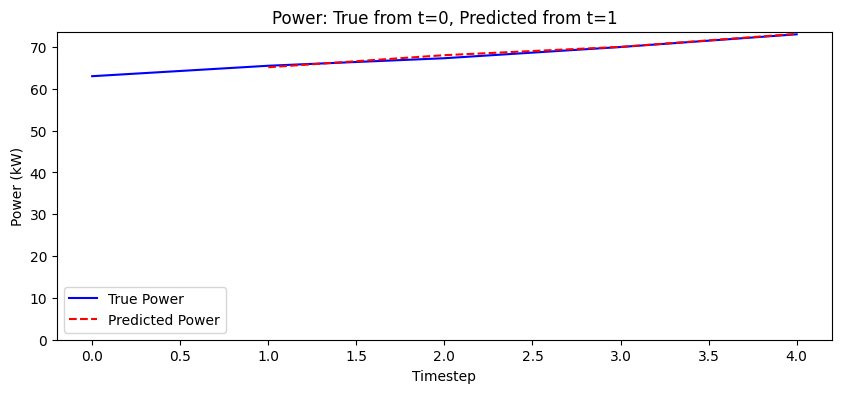

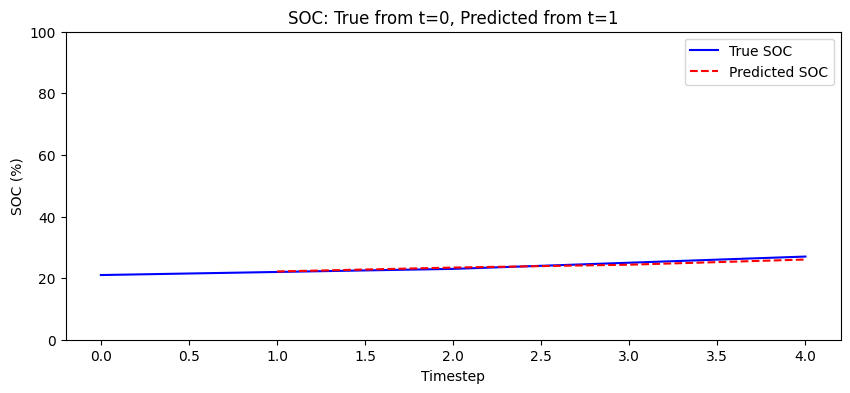

In [17]:
target_length = 5
batch_index = 0
result_dict = predict_session_of_length(
    model=model, dataset=test_dataset, bucket_sampler=test_sampler, 
    target_length=target_length, session_index_of_that_length=batch_index, 
    device=device, power_scaler=power_scaler, soc_scaler=soc_scaler, 
    skip_pred_first_n=1, # skip the first predicted timestep skip_true_first_n=0    
    skip_true_first_n=0, # keep all true timesteps
)

if result_dict:
    t_pred = result_dict["time_axis_pred"]
    t_true = result_dict["time_axis_true"]
    pred_power = result_dict["pred_power"]
    true_power = result_dict["true_power"]
    pred_soc   = result_dict["pred_soc"]
    true_soc   = result_dict["true_soc"]

    # Quick print to see array lengths
    print("Shapes:")
    print(f"  t_true: {t_true.shape},  true_power: {true_power.shape}")
    print(f"  t_pred: {t_pred.shape}, pred_power: {pred_power.shape}")

    # Plot Power
    plt.figure(figsize=(10,4))
    plt.plot(t_true, true_power, label='True Power', color='blue')
    plt.plot(t_pred, pred_power, label='Predicted Power', color='red', linestyle='--')
    plt.xlabel('Timestep')
    plt.ylabel('Power (kW)')
    plt.ylim(bottom=0)
    plt.title('Power: True from t=0, Predicted from t=1')
    plt.legend()
    plt.show()

    # Plot SOC
    plt.figure(figsize=(10,4))
    plt.plot(t_true, true_soc, label='True SOC', color='blue')
    plt.plot(t_pred, pred_soc, label='Predicted SOC', color='red', linestyle='--')
    plt.xlabel('Timestep')
    plt.ylabel('SOC (%)')
    plt.ylim(0, 100)
    plt.title('SOC: True from t=0, Predicted from t=1')
    plt.legend()
    plt.show()
else:
    print(f"No sequences found of length {target_length} at batch index {batch_index}")

In [18]:
def evaluate_model_on_loader(
    model: nn.Module, loader: DataLoader, device: torch.device, 
    power_scaler: MinMaxScaler, soc_scaler: MinMaxScaler, skip_first_n: int = 1
    ):
    """
    Runs inference on all sequences, ignoring padded steps and
    skipping the first `skip_first_n` real timesteps for each sequence.
    Returns MSE, RMSE, R2 for both power and soc.
    """

    model.eval()

    all_pred_power = []
    all_true_power = []
    all_pred_soc   = []
    all_true_soc   = []

    with torch.no_grad():
        for X_batch, Y_batch, lengths in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            lengths = lengths.to(device)

            pred_padded, out_lengths = model(X_batch, lengths)
            B, T_max, _ = pred_padded.shape

            pred_np = pred_padded.cpu().numpy()
            true_np = Y_batch.cpu().numpy()

            for i in range(B):
                valid_len = lengths[i].item()

                # Skip the first `skip_first_n` timesteps
                start_idx = min(skip_first_n, valid_len)
                pred_sub = pred_np[i, start_idx:valid_len, :]  # shape: (valid_len - skip_first_n, output_size)
                true_sub = true_np[i, start_idx:valid_len, :]

                # If session is shorter than skip_first_n, this might be empty
                if pred_sub.shape[0] == 0:
                    continue

                # Inverse transform
                pred_power_unscaled = power_scaler.inverse_transform(pred_sub[:, [0]]).ravel()
                pred_soc_unscaled   = soc_scaler.inverse_transform(pred_sub[:, [1]]).ravel()
                true_power_unscaled = power_scaler.inverse_transform(true_sub[:, [0]]).ravel()
                true_soc_unscaled   = soc_scaler.inverse_transform(true_sub[:, [1]]).ravel()

                all_pred_power.extend(pred_power_unscaled)
                all_true_power.extend(true_power_unscaled)
                all_pred_soc.extend(pred_soc_unscaled)
                all_true_soc.extend(true_soc_unscaled)

    # Computes the metrics on the aggregated arrays
    mse_power  = mean_squared_error(all_true_power, all_pred_power) if all_pred_power else float('nan')
    rmse_power = math.sqrt(mse_power) if all_pred_power else float('nan')
    r2_power   = r2_score(all_true_power, all_pred_power) if all_pred_power else float('nan')

    mse_soc  = mean_squared_error(all_true_soc, all_pred_soc) if all_pred_soc else float('nan')
    rmse_soc = math.sqrt(mse_soc) if all_pred_soc else float('nan')
    r2_soc   = r2_score(all_true_soc, all_pred_soc) if all_pred_soc else float('nan')

    return {
        "MSE_power": mse_power, 
        "RMSE_power": rmse_power,
        "R2_power": r2_power,
        "MSE_soc": mse_soc,
        "RMSE_soc": rmse_soc,
        "R2_soc": r2_soc
    }


In [19]:
test_metrics = evaluate_model_on_loader(
    model=model, loader=test_loader, device=device, power_scaler=power_scaler, 
    soc_scaler=soc_scaler, skip_first_n=1  # skip the first real timestep
)

print("Test metrics:")
for k, v in test_metrics.items():
    print(k, ":", v)

Test metrics:
MSE_power : 23.976574
RMSE_power : 4.8965879900285465
R2_power : 0.9821405241859751
MSE_soc : 0.31000978
RMSE_soc : 0.5567852167092163
R2_soc : 0.9993076415840318
